In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools, time, warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, SimpleRNN, Dense, Dropout, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

print('TF:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))


TF: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ── Load ─────────────────────────────────────────────────────────────────────
df = pd.read_excel("/content/Fifteen_minutes_irradiance_dataset.xlsx")
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime').sort_index()

print('Shape:', df.shape)
print('Range:', df.index.min(), '->', df.index.max())
print('Columns:', df.columns.tolist())
df.head(3)

Shape: (64265, 8)
Range: 2020-03-01 00:00:00 -> 2021-12-31 23:45:00
Columns: ['irr_sensor_1', 'irr_sensor_2', 'irr_sensor_3', 'irr_sensor_4', 'irr_sensor_5', 'irr_sensor_6', 'irradiance_avg', 'source_file']


,irr_sensor_1,irr_sensor_2,irr_sensor_3,irr_sensor_4,irr_sensor_5,irr_sensor_6,irradiance_avg,source_file
datetime,,,,,,,,
2020-03-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,March 2020 Fixed.xlsx
2020-03-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,March 2020 Fixed.xlsx
2020-03-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,March 2020 Fixed.xlsx


In [ ]:
df.head(50)

,irr_sensor_1,irr_sensor_2,irr_sensor_3,irr_sensor_4,irr_sensor_5,irr_sensor_6,irradiance_avg,source_file
datetime,,,,,,,,
2020-03-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,March 2020 Fixed.xlsx
2020-03-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,March 2020 Fixed.xlsx
2020-03-01 00:30:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,March 2020 Fixed.xlsx
2020-03-01 00:45:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,March 2020 Fixed.xlsx
2020-03-01 01:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,March 2020 Fixed.xlsx
2020-03-01 01:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,March 2020 Fixed.xlsx
2020-03-01 01:30:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,March 2020 Fixed.xlsx
2020-03-01 01:45:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,March 2020 Fixed.xlsx
2020-03-01 02:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,March 2020 Fixed.xlsx


In [ ]:
IRR_COLS     = ['irr_sensor_1','irr_sensor_2','irr_sensor_3',
                'irr_sensor_4','irr_sensor_5','irr_sensor_6']
TARGET_COLS  = ['irradiance_avg']

# ── Drop rows where ALL irradiance sensors are NaN ────────────────────────────
df = df.dropna(subset=IRR_COLS, how='all')

# ── Duplicate index fix (9 duplicate timestamps found in EDA) ─────────────────
df = df[~df.index.duplicated(keep='first')]

# ── Fill the small number of NaNs ─────────────────────────────────────────────
day_mask   = (df.index.hour >= 6) & (df.index.hour < 18)
night_mask = ~day_mask


for col in IRR_COLS:
    df.loc[day_mask   & df[col].isna(), col] = df.loc[day_mask,   'irradiance_avg']
    df.loc[night_mask & df[col].isna(), col] = 0


# ── Cyclical time features ─────────────────────────────────────────────────────
df['hour_sin']  = np.sin(2 * np.pi * df.index.hour        / 24)
df['hour_cos']  = np.cos(2 * np.pi * df.index.hour        / 24)
df['month_sin'] = np.sin(2 * np.pi * df.index.month       / 12)
df['month_cos'] = np.cos(2 * np.pi * df.index.month       / 12)
df['minute_sin']= np.sin(2 * np.pi * df.index.minute      / 60)
df['minute_cos']= np.cos(2 * np.pi * df.index.minute      / 60)

FEATURE_COLS = IRR_COLS + ['irradiance_avg',
               'hour_sin','hour_cos','month_sin','month_cos',
               'minute_sin','minute_cos']

df = df[FEATURE_COLS].copy()

print('Final shape:', df.shape)
print('NaNs remaining:', df.isnull().sum().sum())
df.describe().round(3)

Final shape: (64256, 13)
NaNs remaining: 0


,irr_sensor_1,irr_sensor_2,irr_sensor_3,irr_sensor_4,irr_sensor_5,irr_sensor_6,irradiance_avg,hour_sin,hour_cos,month_sin,month_cos,minute_sin,minute_cos
count,64256.000,64256.000,64256.000,64256.000,64256.000,64256.000,64256.000,64256.000,64256.000,64256.000,64256.000,64256.000,64256.000
mean,258.980,259.623,258.784,257.260,254.958,260.812,258.398,-0.000,-0.000,-0.065,-0.062,-0.000,0.000
std,349.959,351.032,348.356,344.822,342.426,349.793,347.511,0.707,0.707,0.703,0.705,0.707,0.707
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000
25%,0.013,0.000,0.000,0.000,0.080,0.000,0.024,-0.707,-0.707,-0.866,-0.866,-0.250,-0.250
50%,8.797,8.280,8.693,9.650,9.360,9.547,9.113,0.000,-0.000,-0.000,-0.000,0.000,0.000
75%,539.000,540.813,535.467,532.040,527.408,542.900,536.496,0.707,0.707,0.500,0.500,0.000,1.000
max,1130.020,1132.160,1135.873,1112.287,1127.207,1139.720,1127.996,1.000,1.000,1.000,1.000,1.000,1.000


In [ ]:
SPLIT = 0.70
split_idx = int(len(df) * SPLIT)
df_train  = df.iloc[:split_idx]
df_test   = df.iloc[split_idx:]
print(f'Train: {len(df_train):,} rows  ({df_train.index.min().date()} -> {df_train.index.max().date()})')
print(f'Test : {len(df_test):,} rows  ({df_test.index.min().date()} -> {df_test.index.max().date()})')

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_sc = scaler_X.fit_transform(df_train[FEATURE_COLS])
X_test_sc  = scaler_X.transform    (df_test [FEATURE_COLS])

y_train_sc = scaler_y.fit_transform(df_train[TARGET_COLS])
y_test_sc  = scaler_y.transform    (df_test [TARGET_COLS])
print('Scaling done.')


Train: 44,979 rows  (2020-03-01 -> 2021-06-13)
Test : 19,277 rows  (2021-06-13 -> 2021-12-31)
Scaling done.


In [ ]:
def make_sequences(X_sc, y_sc, seq_len):
    """Sliding window: returns (n, seq_len, features) and (n, targets)."""
    X_out, y_out = [], []
    for i in range(seq_len, len(X_sc)):
        X_out.append(X_sc[i - seq_len : i])
        y_out.append(y_sc[i])
    return np.array(X_out, np.float32), np.array(y_out, np.float32)

# Quick check
_X, _y = make_sequences(X_train_sc, y_train_sc, 48)
print('Sample X shape:', _X.shape, '  y shape:', _y.shape)

Sample X shape: (44931, 48, 13)   y shape: (44931, 1)


In [ ]:
from tensorflow.keras.layers import LSTM, BatchNormalization, Bidirectional

def build_lstm_model(seq_len, n_features, n_targets,
                     units=64, num_layers=1,
                     dropout=0.0,
                     recurrent_dropout=0.0,   # ✅ NEW
                     bidirectional=False,     # ✅ NEW
                     lr=1e-3):

    model = Sequential()

    # Feature extractor
    model.add(Conv1D(64, kernel_size=1, activation='relu',
                     input_shape=(seq_len, n_features)))

    # LSTM stack
    for i in range(num_layers):
        return_seq = (i < num_layers - 1)

        lstm_layer = LSTM(
            units,
            return_sequences=return_seq,
            activation='tanh',
            dropout=dropout,
            recurrent_dropout=recurrent_dropout   # ✅ NEW
        )

        # Apply bidirectional if selected
        if bidirectional:
            model.add(Bidirectional(lstm_layer))
        else:
            model.add(lstm_layer)

        # Stability
        model.add(BatchNormalization())

    # Output
    model.add(Dense(n_targets))

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae']
    )

    return model

In [ ]:
param_grid_lstm = {
    'seq_length'    : [12, 24, 48],
    'units'         : [32, 64],
    'num_layers'    : [1, 2],
    'dropout'       : [0.0, 0.2, 0.5],
    'learning_rate' : [1e-3],
    'batch_size'    : [32],
}

In [ ]:
param_grid_lstm = {
    'seq_length'        : [12, 24, 48],
    'units'             : [32, 64, 128],
    'num_layers'        : [1, 2, 3],
    'dropout'           : [0.0, 0.2],
    'recurrent_dropout' : [0.0, 0.2],
    'learning_rate'     : [1e-3, 5e-4],
    'batch_size'        : [32],
    'bidirectional'     : [False, True]
}

In [ ]:
import itertools, time
from tensorflow.keras.layers import Bidirectional
keys   = list(param_grid_lstm.keys())
combos = list(itertools.product(*[param_grid_lstm[k] for k in keys]))
MAX_COMBOS = 100
combos = combos[:MAX_COMBOS]
print(f'Running {len(combos)} LSTM combinations')

results_lstm = []
MAX_COMBOS = 100
combos = combos[:MAX_COMBOS]


for idx, combo in enumerate(combos):


    es_cb = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=0
)

    p = dict(zip(keys, combo))
    sq = p['seq_length']

    # Create sequences
    X_tr, y_tr = make_sequences(X_train_sc, y_train_sc, sq)
    X_te, y_te = make_sequences(X_test_sc,  y_test_sc,  sq)



    model = build_lstm_model(
       sq, X_tr.shape[2], y_tr.shape[1],
      units=p['units'],
      num_layers=p['num_layers'],
      dropout=p['dropout'],
      lr=p['learning_rate'],
      recurrent_dropout=p['recurrent_dropout'],   # ✅ NEW
      bidirectional=p['bidirectional']            # ✅ NEW
    )
    # Train
    t0 = time.time()

    hist = model.fit(
        X_tr, y_tr,
        epochs=50,
        batch_size=p['batch_size'],
        validation_split=0.15,
        callbacks=[es_cb],
        verbose=0
    )

    secs = round(time.time() - t0, 1)

    # Predict
    yp_sc = model.predict(X_te, verbose=0)

    yp_real = scaler_y.inverse_transform(yp_sc)
    yt_real = scaler_y.inverse_transform(y_te)

    # Metrics
    mae_norm  = float(mean_absolute_error(y_te, yp_sc))
    rmse_norm = float(np.sqrt(mean_squared_error(y_te, yp_sc)))
    mae_real  = float(mean_absolute_error(yt_real[:,0], yp_real[:,0]))

    # Store results
    row = {
        **p,
        'mae_norm'       : round(mae_norm, 6),
        'rmse_norm'      : round(rmse_norm, 6),
        'mae_irr_Wm2'    : round(mae_real, 4),
        'epochs_ran'     : len(hist.history['loss']),
        'train_sec'      : secs
    }

    results_lstm.append(row)

    print(f'[{idx+1:02d}/{len(combos)}] '
      f'seq={sq:2d} units={p["units"]:3d} layers={p["num_layers"]} '
      f'drop={p["dropout"]} rdrop={p["recurrent_dropout"]} '
      f'bi={p["bidirectional"]} lr={p["learning_rate"]} | '
      f'MAE(norm)={mae_norm:.4f}  irr={mae_real:.1f}W/m²  '
      f'ep={len(hist.history["loss"])}  t={secs}s')

print('\n✅ LSTM Grid Search Complete!')

Running 100 LSTM combinations
[01/100] seq=12 units= 32 layers=1 drop=0.0 rdrop=0.0 bi=False lr=0.001 | MAE(norm)=0.0157  irr=17.7W/m²  ep=24  t=163.2s
[02/100] seq=12 units= 32 layers=1 drop=0.0 rdrop=0.0 bi=True lr=0.001 | MAE(norm)=0.0212  irr=23.9W/m²  ep=22  t=187.9s
[03/100] seq=12 units= 32 layers=1 drop=0.0 rdrop=0.0 bi=False lr=0.0005 | MAE(norm)=0.0125  irr=14.1W/m²  ep=34  t=225.2s
[04/100] seq=12 units= 32 layers=1 drop=0.0 rdrop=0.0 bi=True lr=0.0005 | MAE(norm)=0.0170  irr=19.2W/m²  ep=24  t=205.7s
[05/100] seq=12 units= 32 layers=1 drop=0.0 rdrop=0.2 bi=False lr=0.001 | MAE(norm)=0.0180  irr=20.3W/m²  ep=20  t=633.7s
[06/100] seq=12 units= 32 layers=1 drop=0.0 rdrop=0.2 bi=True lr=0.001 | MAE(norm)=0.0257  irr=29.0W/m²  ep=16  t=919.4s
[07/100] seq=12 units= 32 layers=1 drop=0.0 rdrop=0.2 bi=False lr=0.0005 | MAE(norm)=0.0158  irr=17.8W/m²  ep=21  t=670.9s
[08/100] seq=12 units= 32 layers=1 drop=0.0 rdrop=0.2 bi=True lr=0.0005 | MAE(norm)=0.0133  irr=15.0W/m²  ep=44  t=2

## Best Hyperparameter Results

In [ ]:
results_lstm_df = pd.DataFrame(results_lstm)\
    .sort_values('mae_norm')\
    .reset_index(drop=True)

display(results_lstm_df.head(10))

# Best config
best_lstm = results_lstm_df.iloc[0]

print("="*50)
print("BEST LSTM CONFIG")
print("="*50)

for k, v in best_lstm.items():
    print(f"{k:<20} {v}")

# 8. Final Model Configuration

Epoch 1/100
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - loss: 0.1507 - mae: 0.2633 - val_loss: 0.0178 - val_mae: 0.1113
Epoch 2/100
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 0.0212 - mae: 0.1111 - val_loss: 0.0071 - val_mae: 0.0667
Epoch 3/100
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 0.0127 - mae: 0.0844 - val_loss: 0.0033 - val_mae: 0.0410
Epoch 4/100
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 0.0099 - mae: 0.0729 - val_loss: 0.0032 - val_mae: 0.0373
Epoch 5/100
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 0.0082 - mae: 0.0660 - val_loss: 0.0021 - val_mae: 0.0328
Epoch 6/100
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 0.0071 - mae: 0.0615 - val_loss: 0.0021 - val_mae: 0.0270
Epoch 7/100
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 0.0067 - mae: 0.0599 - val_loss: 0.0016 - val_mae: 0.0283
Epoch 8/100
1194/1194 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 0.0063 - mae: 0.0579 - val_loss: 0.0023 - val_mae: 0.0287
Epoch 9/100
1194

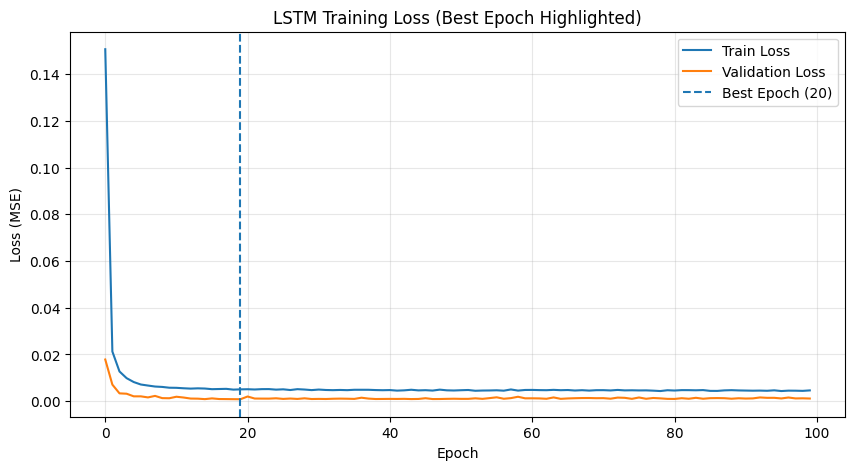

In [ ]:
# =========================
# FINAL LSTM TRAINING + BEST EPOCH TRACKING
# =========================

from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt


# the approved one for now

# Extract best params
B_SEQ   =  48 #int(best_lstm['seq_length'])
B_UNITS =   32 #int(best_lstm['units'])
B_LAY   = 2 #int(best_lstm['num_layers'])
B_DROP  =  0.5 #float(best_lstm['dropout'])
B_LR    =  0.001 #float(best_lstm['learning_rate'])
B_BS    = 32  #int(best_lstm['batch_size'])

# Create sequences
X_tr_b, y_tr_b = make_sequences(X_train_sc, y_train_sc, B_SEQ)
X_te_b, y_te_b = make_sequences(X_test_sc,  y_test_sc,  B_SEQ)

# Build model
best_model_lstm = build_lstm_model(
    B_SEQ, X_tr_b.shape[2], y_tr_b.shape[1],
    units=B_UNITS,
    num_layers=B_LAY,
    dropout=B_DROP,
    lr=B_LR
)



# Train
history_lstm = best_model_lstm.fit(
    X_tr_b, y_tr_b,
    epochs=100,
    batch_size=B_BS,
    validation_split=0.15,
    verbose=1
)

# =========================
# ANALYZE TRAINING
# =========================

train_loss = history_lstm.history['loss']
val_loss   = history_lstm.history['val_loss']

# Best epoch (lowest validation loss)
best_epoch = np.argmin(val_loss) + 1   # +1 because epochs start at 1

# Total epochs run
epochs_ran = len(train_loss)

print("\n" + "="*50)
print("TRAINING SUMMARY")
print("="*50)
print(f"Best Epoch        : {best_epoch}")
print(f"Stopped At Epoch  : {epochs_ran}")
print(f"Best Val Loss     : {min(val_loss):.6f}")
print(f"Final Val Loss    : {val_loss[-1]:.6f}")
print(f"✔ Weights restored from epoch {best_epoch}")
print("="*50)

# =========================
# PLOT LOSS + BEST EPOCH
# =========================

plt.figure(figsize=(10,5))

plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')

# Highlight best epoch
plt.axvline(best_epoch-1, linestyle='--', label=f'Best Epoch ({best_epoch})')

plt.title('LSTM Training Loss (Best Epoch Highlighted)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

# 10. Model Predictions

In [ ]:
from sklearn.metrics import r2_score

# =========================
# PREDICTIONS
# =========================
y_pred_sc = best_model_lstm.predict(X_te_b, verbose=0)

# Back to real scale
y_pred = scaler_y.inverse_transform(y_pred_sc)
y_true = scaler_y.inverse_transform(y_te_b)

# Flatten (important for sklearn metrics)
y_pred = y_pred[:, 0]
y_true = y_true[:, 0]

# =========================
# METRICS
# =========================
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)

# =========================
# OUTPUT
# =========================
print("\n" + "="*50)
print("FINAL LSTM MODEL PERFORMANCE")
print("="*50)
print(f"MAE   : {mae:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"R²    : {r2:.4f}")



FINAL LSTM MODEL PERFORMANCE
MAE   : 20.5494
RMSE  : 38.0835
R²    : 0.9877


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# =========================
# DAYTIME (y > 50)
# =========================
day_mask = y_true > 50

y_true_day = y_true[day_mask]
y_pred_day = y_pred[day_mask]

mae_day  = mean_absolute_error(y_true_day, y_pred_day)
rmse_day = np.sqrt(mean_squared_error(y_true_day, y_pred_day))
r2_day   = r2_score(y_true_day, y_pred_day)

mape_day = np.mean(
    np.abs((y_true_day - y_pred_day) / (y_true_day + 1e-8))
) * 100

# =========================
# NIGHTTIME (y ≤ 50)
# =========================
night_mask = y_true <= 50

y_true_night = y_true[night_mask]
y_pred_night = y_pred[night_mask]

mae_night  = mean_absolute_error(y_true_night, y_pred_night)
rmse_night = np.sqrt(mean_squared_error(y_true_night, y_pred_night))


if np.var(y_true_night) < 1e-6:
    r2_night = None
else:
    r2_night = r2_score(y_true_night, y_pred_night)

epsilon = 10
mask_valid = y_true_night > epsilon

if np.sum(mask_valid) > 0:
    mape_night = np.mean(
        np.abs((y_true_night[mask_valid] - y_pred_night[mask_valid]) /
               y_true_night[mask_valid])
    ) * 100
else:
    mape_night = None



print("\n" + "="*50)
print("DAYTIME PERFORMANCE (>50 W/m²)")
print("="*50)
print(f"MAE   : {mae_day:.2f}")
print(f"RMSE  : {rmse_day:.2f}")
print(f"R²    : {r2_day:.4f}")
print(f"MAPE  : {mape_day:.2f}%")

print("\n" + "="*50)
print("NIGHTTIME PERFORMANCE (≤50 W/m²)")
print("="*50)
print(f"MAE   : {mae_night:.4f}")
print(f"RMSE  : {rmse_night:.4f}")

if r2_night is None:
    print("R²    : Undefined (near-constant values)")
else:
    print(f"R²    : {r2_night:.4f}")

if mape_night is None:
    print("MAPE  : Undefined (no valid non-zero points)")
else:
    print(f"MAPE  : {mape_night:.2f}%")


DAYTIME PERFORMANCE (>50 W/m²)
MAE   : 49.82
RMSE  : 68.29
R²    : 0.9470
MAPE  : 11.17%

NIGHTTIME PERFORMANCE (≤50 W/m²)
MAE   : 11.3645
RMSE  : 12.5116
R²    : -1.2309
MAPE  : 70.00%


## Export Predictions to CSV

In [ ]:
# =========================
# PREDICTIONS + CSV EXPORT
# =========================

# Predict (scaled → real)
yp_sc   = best_model_lstm.predict(X_te_b, verbose=0)
yp_real = scaler_y.inverse_transform(yp_sc)

yt_real = scaler_y.inverse_transform(y_te_b)

# -------------------------
# FIX DATETIME ALIGNMENT
# -------------------------
# Because of sequence length, first B_SEQ timestamps are lost

test_index = df_test.index[B_SEQ:]   # align with predictions

# -------------------------
# CREATE DATAFRAME
# -------------------------
results_df = pd.DataFrame({
    'datetime'        : test_index,
    'actual_irradiance'   : yt_real[:,0],
    'predicted_irradiance': yp_real[:,0]
})

# Set datetime as index
results_df = results_df.set_index('datetime')

# -------------------------
# SAVE TO CSV
# -------------------------
results_df.to_csv('lstm_predictions_irradiance.csv')

print("✅ CSV saved: lstm_predictions_irradiance.csv")
print(results_df.head())

✅ CSV saved: lstm_predictions_irradiance.csv
                     actual_irradiance  predicted_irradiance
datetime                                                    
2021-06-13 17:00:00         328.813324            318.125671
2021-06-13 17:15:00         274.374451            279.083130
2021-06-13 17:30:00         221.113327            232.264191
2021-06-13 17:45:00         169.495560            174.878891
2021-06-13 18:00:00         121.644447            121.051483



## Additional functionality: Saving the trained model and forecasting on new data

This section adds code to save the final trained LSTM model, reload it later, and use it to make forecasts on a separate two‑month dataset that has the same structure as the original training data.  The workflow follows these steps:

1. **Saving the trained model** – After training the `best_model_lstm`, we persist it using Python's `pickle` module.  Note that the TensorFlow documentation recommends using `model.save()` for Keras models instead of pickling【38385012145996†L269-L274】.  The example below demonstrates both approaches.
2. **Loading the saved model** – We reload the model from disk so it can be used to generate future predictions.
3. **Preparing a new two‑month dataset** – The code shows how to load a new dataset, perform the same cleaning and feature engineering (cyclical time features and filling missing values) as the original training data, and scale the features using the previously fitted `MinMaxScaler` objects.
4. **Creating input sequences** – We use the same sequence length `B_SEQ` and the helper `make_sequences()` to transform the new scaled data into the shape expected by the LSTM model.
5. **Predicting irradiance and converting back to original units** – The scaled predictions are converted back to the original irradiance units using `scaler_y.inverse_transform()`.  According to scikit‑learn's `MinMaxScaler` documentation, `inverse_transform()` undoes the scaling and returns the original data【876100377890579†L913-L927】.
6. **Saving the forecast results** – A DataFrame containing timestamps, actual irradiance values, and predicted irradiance values is created and saved to a CSV file for further analysis.



In [ ]:
import pandas as pd
new_df = pd.read_excel('/content/Fifteen_minutes_merged_2020-2022.xlsx')
new_df

,datetime,irr_sensor_1,irr_sensor_2,irr_sensor_3,irr_sensor_4,irr_sensor_5,irr_sensor_6,irradiation_tilted,power_analyzer,generated_yield,avg_module_temp,irradiance_avg,source_file
0,2020-03-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.882214,0.0,12.422857,0.0,March 2020 Fixed.xlsx
1,2020-03-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.042200,0.0,11.410667,0.0,March 2020 Fixed.xlsx
2,2020-03-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.621000,0.0,11.336000,0.0,March 2020 Fixed.xlsx
3,2020-03-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.347733,0.0,11.243333,0.0,March 2020 Fixed.xlsx
4,2020-03-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.290000,0.0,11.357333,0.0,March 2020 Fixed.xlsx
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69605,2022-02-24 22:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.201133,0.0,10.806000,0.0,febraury 2022 fixed.xlsx
69606,2022-02-24 23:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.968867,0.0,10.736667,0.0,febraury 2022 fixed.xlsx
69607,2022-02-24 23:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.601133,0.0,10.620667,0.0,febraury 2022 fixed.xlsx
69608,2022-02-24 23:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.980000,0.0,9.852000,0.0,febraury 2022 fixed.xlsx


In [ ]:

# === Save the trained LSTM model ===
# Using pickle (not the recommended method for Keras models)
import pickle
with open('best_model_lstm.pkl', 'wb') as f:
    pickle.dump(best_model_lstm, f)

# Recommended: use Keras native save format
# This creates a `.keras` file containing the model architecture, weights, and optimizer state
best_model_lstm.save('best_model_lstm.keras')
print('✅ Model saved (pickle and Keras formats).')


✅ Model saved (pickle and Keras formats).


In [ ]:

# === Load the saved LSTM model ===
# Option 1: load the pickled model
import pickle
with open('/content/best_model_lstm_irradiance_pkl.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Option 2: load the Keras `.keras` file
# loaded_model = tf.keras.models.load_model('best_model_lstm.keras')
print('✅ Model loaded.')


✅ Model loaded.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools, time, warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, SimpleRNN, Dense, Dropout, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
def make_sequences(X_sc, y_sc, seq_len):
    """Sliding window: returns (n, seq_len, features) and (n, targets)."""
    X_out, y_out = [], []
    for i in range(seq_len, len(X_sc)):
        X_out.append(X_sc[i - seq_len : i])
        y_out.append(y_sc[i])
    return np.array(X_out, np.float32), np.array(y_out, np.float32)



In [ ]:
import pandas as pd
import numpy as np
# === Forecast irradiance on a new two‑month dataset ===
# Replace the file path below with the actual path to your new data file
#new_df = pd.read_excel('/content/Fifteen_minutes_irradiance_dataset_2022.xlsx')



# Convert datetime and set as index (only if 'datetime' is a column)
if 'datetime' in new_df.columns:
    new_df['datetime'] = pd.to_datetime(new_df['datetime'])
    new_df = new_df.set_index('datetime').sort_index()

IRR_COLS     = ['irr_sensor_1','irr_sensor_2','irr_sensor_3',
                'irr_sensor_4','irr_sensor_5','irr_sensor_6']
TARGET_COLS  = ['irradiance_avg']




# ----------- Data cleaning (same as used for the training set) -----------
# Drop rows where all irradiance sensors are missing
new_df = new_df.dropna(subset=IRR_COLS, how='all')
# Remove duplicate timestamps
new_df = new_df[~new_df.index.duplicated(keep='first')]


# Fill NaNs using daytime irradiance average and zero at night
_day_mask   = (new_df.index.hour >= 6) & (new_df.index.hour < 18)
_night_mask = ~_day_mask
for col in IRR_COLS:
    new_df.loc[_day_mask   & new_df[col].isna(), col] = new_df.loc[_day_mask,   'irradiance_avg']
    new_df.loc[_night_mask & new_df[col].isna(), col] = 0

# Create cyclical time features
new_df['hour_sin']   = np.sin(2 * np.pi * new_df.index.hour   / 24)
new_df['hour_cos']   = np.cos(2 * np.pi * new_df.index.hour   / 24)
new_df['month_sin']  = np.sin(2 * np.pi * new_df.index.month  / 12)
new_df['month_cos']  = np.cos(2 * np.pi * new_df.index.month  / 12)
new_df['minute_sin'] = np.sin(2 * np.pi * new_df.index.minute / 60)
new_df['minute_cos'] = np.cos(2 * np.pi * new_df.index.minute / 60)

FEATURE_COLS = IRR_COLS + ['irradiance_avg',
               'hour_sin','hour_cos','month_sin','month_cos',
               'minute_sin','minute_cos']

# Select the same feature columns used for training
new_df = new_df[FEATURE_COLS].copy()


SPLIT = 0.70
split_idx = int(len(new_df) * SPLIT)
new_df_train  = new_df.iloc[:split_idx]
new_df_test   = new_df.iloc[split_idx:]
print(f'Train: {len(new_df_train):,} rows  ({new_df_train.index.min().date()} -> {new_df_train.index.max().date()})')
print(f'Test : {len(new_df_test):,} rows  ({new_df_test.index.min().date()} -> {new_df_test.index.max().date()})')

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_sc = scaler_X.fit_transform(new_df_train[FEATURE_COLS])
X_test_sc  = scaler_X.transform    (new_df_test [FEATURE_COLS])

y_train_sc = scaler_y.fit_transform(new_df_train[TARGET_COLS])
y_test_sc  = scaler_y.transform    (new_df_test [TARGET_COLS])
print('Scaling done.')

# ----------- Scaling using existing scalers -----------
# Scale features and target using the fitted scalers from the original training data
X_new_sc = scaler_X.transform(new_df[FEATURE_COLS])
y_new_sc = scaler_y.transform(new_df[TARGET_COLS])

# Create sequences of length 48
X_new_seq, y_new_seq = make_sequences(X_new_sc, y_new_sc, 48)

# Make predictions
y_new_pred_sc = loaded_model.predict(X_new_seq, verbose=0)

# Convert predictions back to the original scale
# inverse_transform undoes the scaling【876100377890579†L913-L927】
y_new_pred = scaler_y.inverse_transform(y_new_pred_sc)
y_new_true = scaler_y.inverse_transform(y_new_seq)

# Flatten arrays for easier comparison
y_new_pred = y_new_pred[:, 0]
y_new_true = y_new_true[:, 0]

# Align the datetime index (drop the first B_SEQ timestamps lost due to sequence length)
new_index = new_df.index[48:]

# Create a DataFrame with actual and predicted values
results_new_df = pd.DataFrame({
    'datetime'            : new_index,
    'actual_irradiance'   : y_new_true,
    'predicted_irradiance': y_new_pred
}).set_index('datetime')

## Save the results to a CSV file
#results_new_df.to_csv('lstm_predictions_new_data.csv')
#print('✅ Forecast results saved to lstm_predictions_new_data.csv')
#print(results_new_df.head())

Train: 48,675 rows  (2020-03-01 -> 2021-07-21)
Test : 20,861 rows  (2021-07-21 -> 2022-02-24)
Scaling done.


In [ ]:

# Run this AFTER:
# 1) preprocessing/scaling cells are run
# 2) the model is trained OR loaded
#
# Output CSV:
# recursive_1year_irradiance_forecast.csv
# =========================================================


# ---------------------------------------------------------
# Safety checks: make sure required objects already exist
# ---------------------------------------------------------
required_objects = ["new_df", "FEATURE_COLS", "IRR_COLS", "scaler_X", "scaler_y", "make_sequences"]
missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise NameError(
        "Please run the earlier preprocessing/scaling cells first. Missing: "
        + ", ".join(missing_objects)
    )

# Choose trained model or loaded model
if "loaded_model" in globals():
    model_for_forecast = loaded_model
    print("✅ Using loaded_model for forecasting.")
elif "best_model_lstm" in globals():
    model_for_forecast = best_model_lstm
    print("✅ Using best_model_lstm for forecasting.")
else:
    raise NameError("Please train the model or load the saved model before running this forecast cell.")

# Sequence length used in your approved model
SEQ_LEN = B_SEQ if "B_SEQ" in globals() else 48

# 15-minute data: 4 readings/hour * 24 hours/day * 365 days
N_STEPS = 365 * 24 * 4

# Start from the cleaned/prepared data already used in this notebook
history_df = new_df.copy()
history_df = history_df[FEATURE_COLS].copy()
history_df = history_df.sort_index()

# Last timestamp in your current dataset
last_time = history_df.index[-1]

future_dates = []
future_predictions = []

# ---------------------------------------------------------
# Recursive forecasting loop
# Each new prediction becomes the input for the next step
# ---------------------------------------------------------
for step in range(N_STEPS):

    # Take the last sequence window
    last_window = history_df[FEATURE_COLS].iloc[-SEQ_LEN:]

    # Scale using the OLD scaler from training
    X_window_sc = scaler_X.transform(last_window)
    X_window_sc = X_window_sc.reshape(1, SEQ_LEN, len(FEATURE_COLS))

    # Predict next irradiance value
    pred_sc = model_for_forecast.predict(X_window_sc, verbose=0)
    pred_value = scaler_y.inverse_transform(pred_sc)[0, 0]

    # Irradiance cannot be negative
    pred_value = max(float(pred_value), 0.0)

    # Next 15-minute timestamp
    next_time = last_time + pd.Timedelta(minutes=15)

    # Build the next row
    # Future sensor values are unknown, so we use the predicted irradiance
    # as the estimated value for all irradiance sensor inputs.
    new_row = {}

    for col in IRR_COLS:
        new_row[col] = pred_value

    new_row["irradiance_avg"] = pred_value

    # Future time features
    new_row["hour_sin"] = np.sin(2 * np.pi * next_time.hour / 24)
    new_row["hour_cos"] = np.cos(2 * np.pi * next_time.hour / 24)
    new_row["month_sin"] = np.sin(2 * np.pi * next_time.month / 12)
    new_row["month_cos"] = np.cos(2 * np.pi * next_time.month / 12)
    new_row["minute_sin"] = np.sin(2 * np.pi * next_time.minute / 60)
    new_row["minute_cos"] = np.cos(2 * np.pi * next_time.minute / 60)

    # Add predicted row back into history for the next recursive step
    history_df.loc[next_time, FEATURE_COLS] = [new_row[col] for col in FEATURE_COLS]

    # Store forecast result
    future_dates.append(next_time)
    future_predictions.append(pred_value)

    # Update last timestamp
    last_time = next_time

# ---------------------------------------------------------
# CSV export

forecast_1year_df = pd.DataFrame({
    "datetime": future_dates,
    "forecasted_irradiance": future_predictions
}).set_index("datetime")

FORECAST_CSV_NAME = "recursive_1year_irradiance_forecast.csv"
forecast_1year_df.to_csv(FORECAST_CSV_NAME)

print(f"✅ Forecast CSV saved as: {FORECAST_CSV_NAME}")
print(f"✅ Number of forecasted rows: {len(forecast_1year_df):,}")


✅ Using loaded_model for forecasting.
✅ Forecast CSV saved as: recursive_1year_irradiance_forecast.csv
✅ Number of forecasted rows: 35,040


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# =========================================================
# Use the actual variable names from your LSTM prediction code
# =========================================================

# Your variables are:
# y_new_true = actual values
# y_new_pred = predicted values

y_true = y_new_true
y_pred = y_new_pred

# =========================================================
# DAYTIME PERFORMANCE (irradiance > 50 W/m²)
# =========================================================

day_mask = y_true > 50

y_true_day = y_true[day_mask]
y_pred_day = y_pred[day_mask]

mae_day = mean_absolute_error(y_true_day, y_pred_day)
rmse_day = np.sqrt(mean_squared_error(y_true_day, y_pred_day))
r2_day = r2_score(y_true_day, y_pred_day)

# Safe MAPE calculation
mape_day = np.mean(
    np.abs((y_true_day - y_pred_day) / (y_true_day + 1e-8))
) * 100


# =========================================================
# NIGHTTIME PERFORMANCE (irradiance ≤ 50 W/m²)
# =========================================================

night_mask = y_true <= 50

y_true_night = y_true[night_mask]
y_pred_night = y_pred[night_mask]

mae_night = mean_absolute_error(y_true_night, y_pred_night)
rmse_night = np.sqrt(mean_squared_error(y_true_night, y_pred_night))

# R² becomes unstable if values are nearly constant
if np.var(y_true_night) < 1e-6:
    r2_night = None
else:
    r2_night = r2_score(y_true_night, y_pred_night)

# MAPE for nighttime:
# ignore very tiny values because percentage explodes near zero
epsilon = 10
mask_valid = y_true_night > epsilon

if np.sum(mask_valid) > 0:
    mape_night = np.mean(
        np.abs(
            (y_true_night[mask_valid] - y_pred_night[mask_valid]) /
            y_true_night[mask_valid]
        )
    ) * 100
else:
    mape_night = None


# =========================================================
# PRINT RESULTS
# =========================================================

print("\n" + "=" * 50)
print("DAYTIME PERFORMANCE (>50 W/m²)")
print("=" * 50)
print(f"MAE   : {mae_day:.2f}")
print(f"RMSE  : {rmse_day:.2f}")
print(f"R²    : {r2_day:.4f}")
print(f"MAPE  : {mape_day:.2f}%")


print("\n" + "=" * 50)
print("NIGHTTIME PERFORMANCE (≤50 W/m²)")
print("=" * 50)
print(f"MAE   : {mae_night:.4f}")
print(f"RMSE  : {rmse_night:.4f}")

if r2_night is None:
    print("R²    : Undefined (near-constant values)")
else:
    print(f"R²    : {r2_night:.4f}")

if mape_night is None:
    print("MAPE  : Undefined (no valid non-zero points)")
else:
    print(f"MAPE  : {mape_night:.2f}%")


DAYTIME PERFORMANCE (>50 W/m²)
MAE   : 80.78
RMSE  : 106.43
R²    : 0.8424
MAPE  : 23.46%

NIGHTTIME PERFORMANCE (≤50 W/m²)
MAE   : 12.4685
RMSE  : 20.4006
R²    : -6.0136
MAPE  : 167.74%


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# =========================
# PREDICTIONS
# =========================

# Use your actual model variable from previous code
y_new_pred_sc = loaded_model.predict(X_new_seq, verbose=0)

# Back to real scale
y_new_pred = scaler_y.inverse_transform(y_new_pred_sc)
y_new_true = scaler_y.inverse_transform(y_new_seq)

# Flatten (important for sklearn metrics)
y_new_pred = y_new_pred[:, 0]
y_new_true = y_new_true[:, 0]

# =========================
# METRICS
# =========================

mae = mean_absolute_error(y_new_true, y_new_pred)
rmse = np.sqrt(mean_squared_error(y_new_true, y_new_pred))
r2 = r2_score(y_new_true, y_new_pred)

# =========================
# OUTPUT
# =========================

print("\n" + "=" * 50)
print("FINAL LSTM MODEL PERFORMANCE")
print("=" * 50)
print(f"MAE   : {mae:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"R²    : {r2:.4f}")


FINAL LSTM MODEL PERFORMANCE
MAE   : 38.9350
RMSE  : 68.1443
R²    : 0.9470


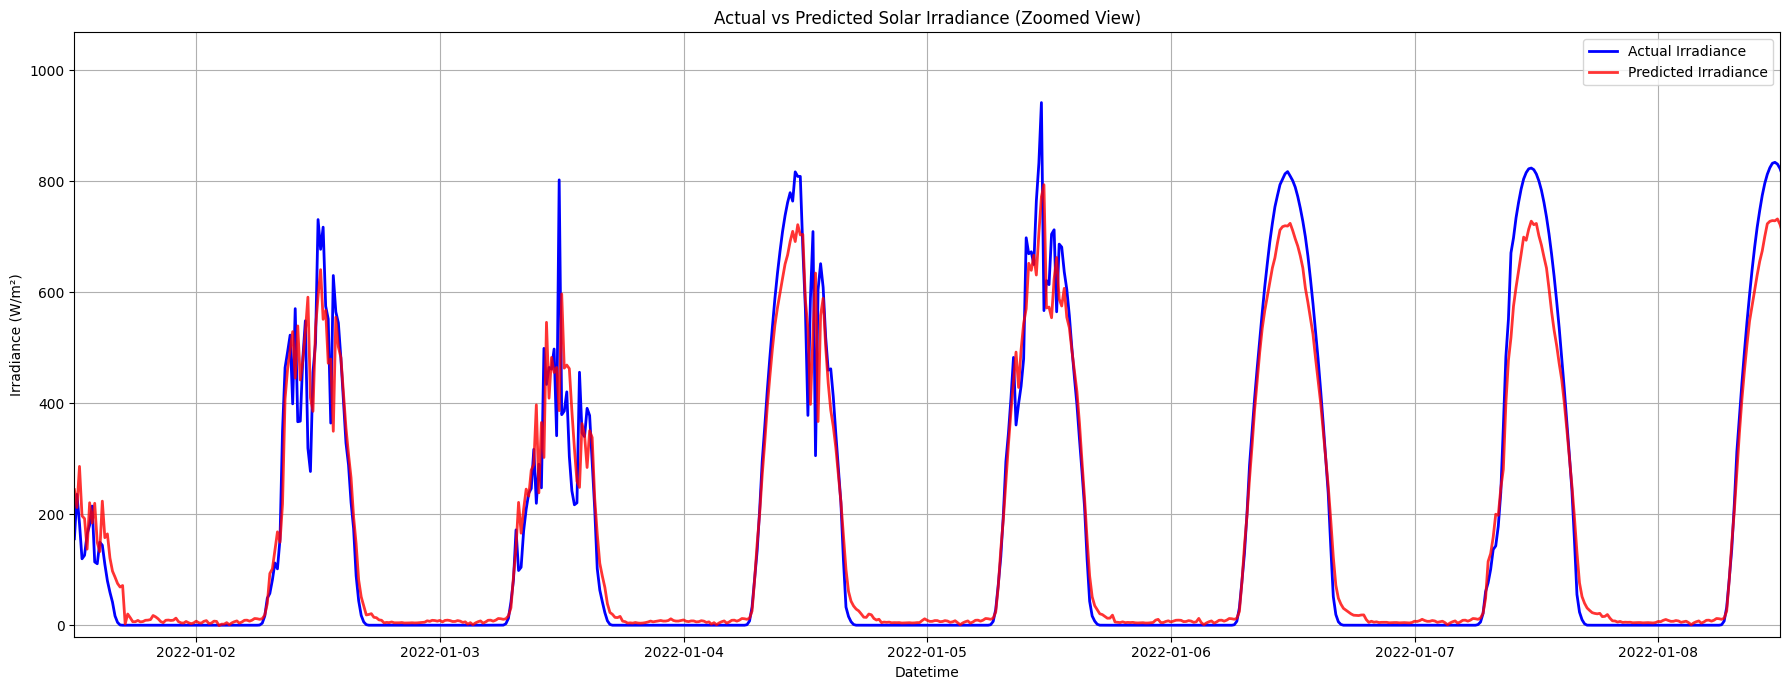

In [ ]:
import matplotlib.pyplot as plt

# =========================================================
# GRAPH 1: ACTUAL vs PREDICTED (ZOOMED + CLEAR COLORS)
# Better visibility for comparing both lines
# =========================================================

plt.figure(figsize=(18,7))

# Use stronger colors and slightly thicker lines
plt.plot(
    results_new_df.index,
    y_new_true,
    label='Actual Irradiance',
    color='blue',
    linewidth=2
)

plt.plot(
    results_new_df.index,
    y_new_pred,
    label='Predicted Irradiance',
    color='red',
    linewidth=2,
    alpha=0.8
)

# Tight vertical scaling for better visibility
y_min = min(np.min(y_new_true), np.min(y_new_pred))
y_max = max(np.max(y_new_true), np.max(y_new_pred))

plt.ylim(y_min - 20, y_max + 20)

# Optional: zoom horizontally by selecting a smaller range
# Example: first 7 days only (much clearer visually)
plt.xlim(
    results_new_df.index.min(),
    results_new_df.index.min() + pd.Timedelta(days=7)
)

plt.title("Actual vs Predicted Solar Irradiance (Zoomed View)")
plt.xlabel("Datetime")
plt.ylabel("Irradiance (W/m²)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




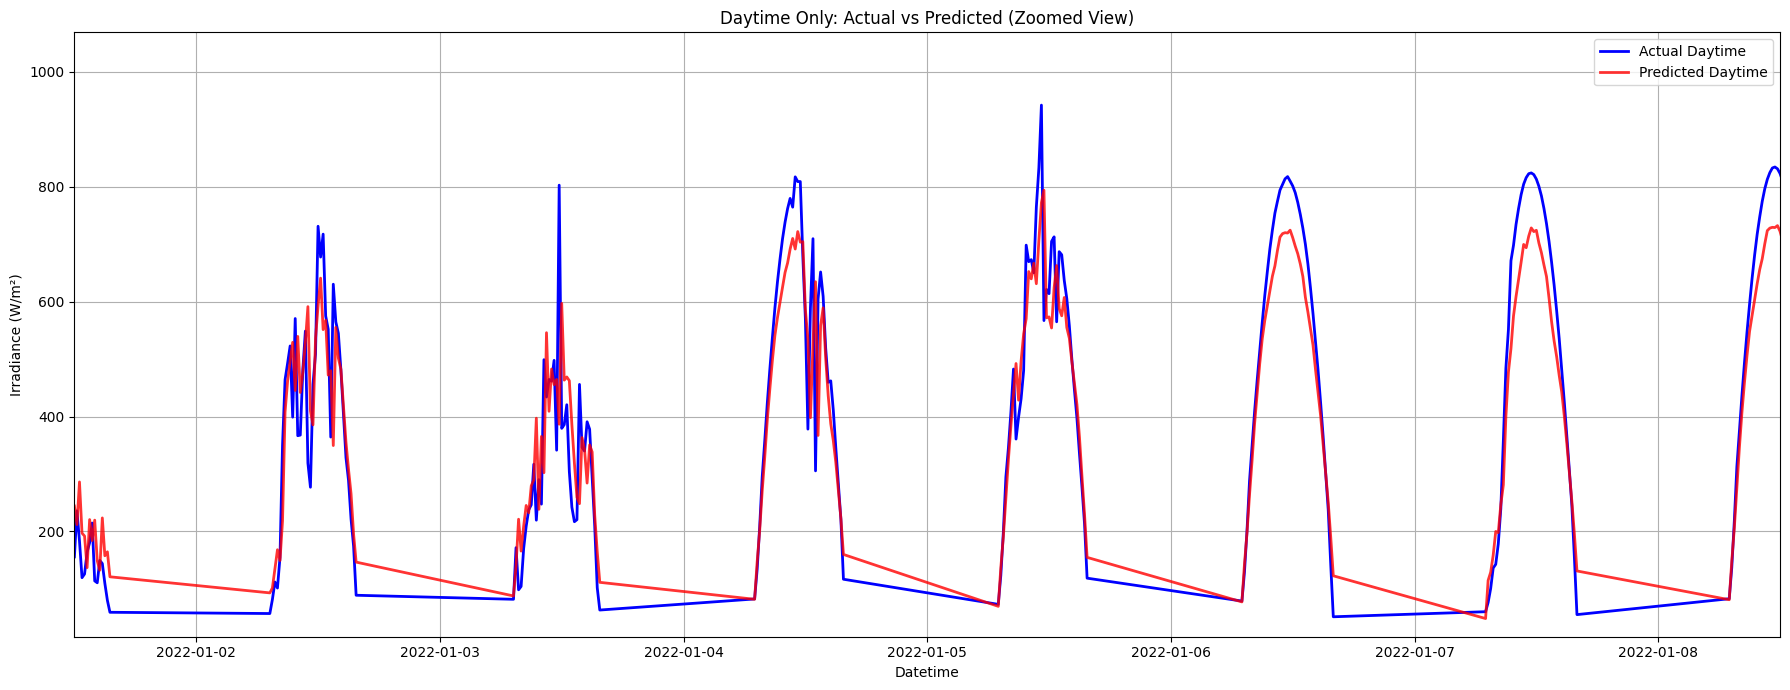

In [ ]:
# =import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =========================================================
# GRAPH 5: DAYTIME ONLY ACTUAL vs PREDICTED
# ZOOMED + CLEAR COLORS + BETTER VISIBILITY
# =========================================================

day_mask = y_new_true > 50

plt.figure(figsize=(18,7))

# Actual values
plt.plot(
    results_new_df.index[day_mask],
    y_new_true[day_mask],
    label='Actual Daytime',
    color='blue',
    linewidth=2
)

# Predicted values
plt.plot(
    results_new_df.index[day_mask],
    y_new_pred[day_mask],
    label='Predicted Daytime',
    color='red',
    linewidth=2,
    alpha=0.8
)

# Better vertical zoom
y_day_min = min(np.min(y_new_true[day_mask]), np.min(y_new_pred[day_mask]))
y_day_max = max(np.max(y_new_true[day_mask]), np.max(y_new_pred[day_mask]))

plt.ylim(y_day_min - 20, y_day_max + 20)

# Better horizontal zoom (example: first 7 daytime days)
plt.xlim(
    results_new_df.index[day_mask].min(),
    results_new_df.index[day_mask].min() + pd.Timedelta(days=7)
)

plt.title("Daytime Only: Actual vs Predicted (Zoomed View)")
plt.xlabel("Datetime")
plt.ylabel("Irradiance (W/m²)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

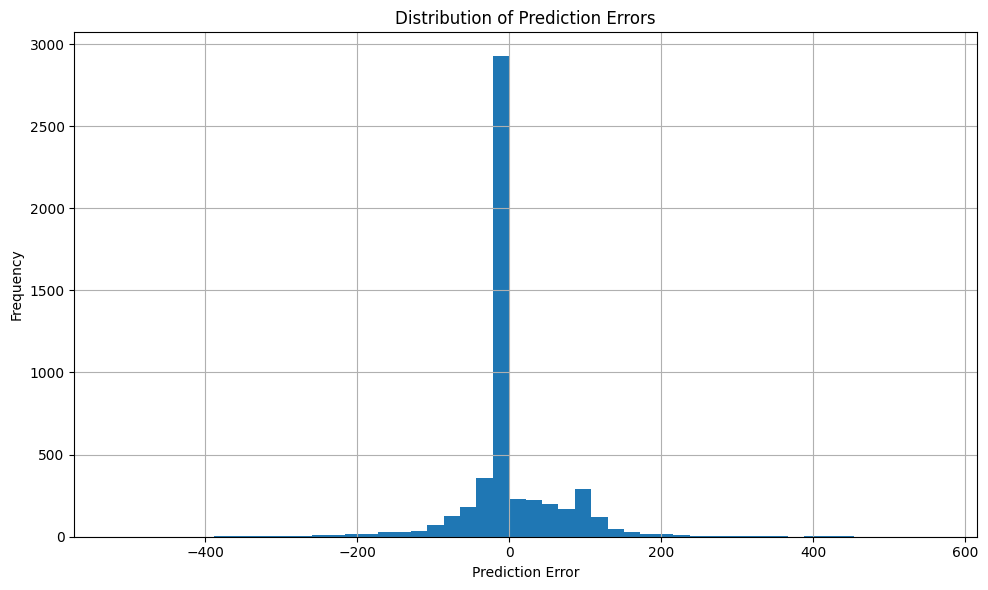

In [ ]:
# =========================================================
# GRAPH 4: HISTOGRAM OF ERRORS
# Shows error distribution
# Ideal = centered around zero
# =========================================================

plt.figure(figsize=(10,6))
plt.hist(residuals, bins=50)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()
